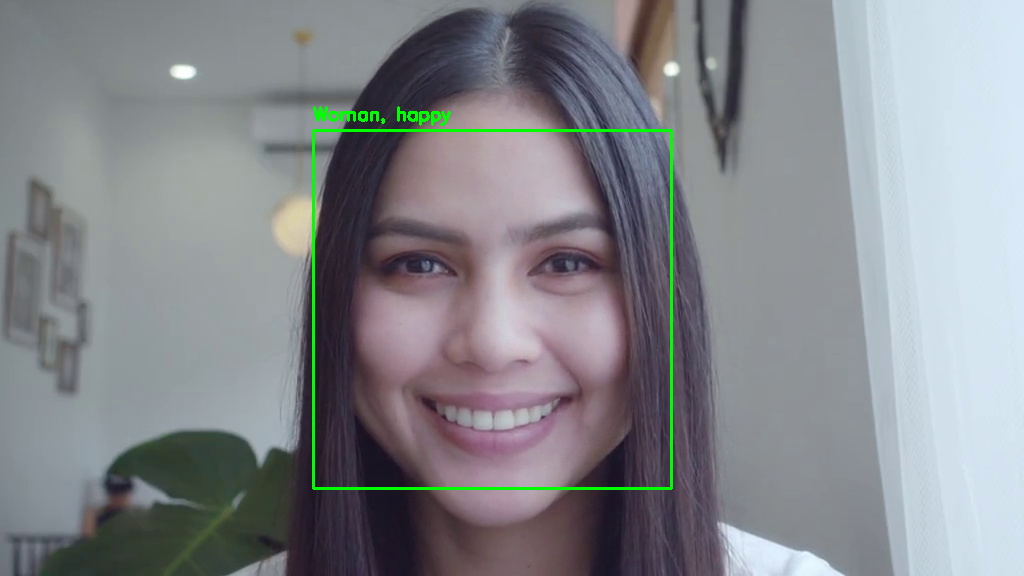

Processing Complete.


In [1]:
!pip install deepface opencv-python-headless --quiet
from deepface import DeepFace
import cv2
from google.colab.patches import cv2_imshow
from IPython.display import clear_output

# Path to your video
video_path = "https://confrecordings.ams3.digitaloceanspaces.com/portrait-of-beautiful-young-woman-is-smiling-in-coffee-shop-slow-motion-free-video.mp4"

cap = cv2.VideoCapture(video_path)
frame_skip = 10  # Process every 10th frame to speed up execution
count = 0

print("Processing Video... (Results will update below)")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Only analyze every Nth frame
    if count % frame_skip == 0:
        try:
            # Analyze emotion and gender
            results = DeepFace.analyze(frame, actions=['emotion', 'gender'], enforce_detection=False, silent=True)

            # DeepFace returns a list if multiple faces are found
            if not isinstance(results, list):
                results = [results]

            for face in results:
                # Extract coordinates for the bounding box
                x, y, w, h = face['region']['x'], face['region']['y'], face['region']['w'], face['region']['h']
                emotion = face['dominant_emotion']
                gender = face['dominant_gender']

                # Draw Rectangle and Text
                cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
                cv2.putText(frame, f"{gender}, {emotion}", (x, y - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

            # Clear previous output and show current frame
            clear_output(wait=True)
            cv2_imshow(frame)

        except Exception as e:
            print(f"Error at frame {count}: {e}")

    count += 1

cap.release()
print("Processing Complete.")